In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

folder_path = r"D:\OneDrive\Trading\Market Making\data\runs\run_20260615_154932"

snapshots = pd.read_parquet(os.path.join(folder_path, "snapshots.parquet"))

snapshots

,ts,symbol,best_bid,best_ask,mid,microprice,best_bid_tick,best_ask_tick,mid_tick,spread,...,ask_delta,quote_churn,future_mid_100ms,future_return_100ms,future_mid_500ms,future_return_500ms,future_mid_1000ms,future_return_1000ms,future_mid_5000ms,future_return_5000ms
0,1781516013114,BTCUSDT,65606.06,65606.07,65606.065,65606.064810,6560606,6560607,6560606,0.01,...,0.0,0.0,65606.065,0.0,65606.065,0.000000,65614.875,0.000134,65609.215,0.000048
1,1781516013214,BTCUSDT,65606.06,65606.07,65606.065,65606.064869,6560606,6560607,6560606,0.01,...,0.0,0.0,65606.065,0.0,65606.065,0.000000,65614.875,0.000134,65606.685,0.000009
2,1781516013314,BTCUSDT,65606.06,65606.07,65606.065,65606.064708,6560606,6560607,6560606,0.01,...,0.0,0.0,65606.065,0.0,65606.065,0.000000,65614.875,0.000134,65606.685,0.000009
3,1781516013414,BTCUSDT,65606.06,65606.07,65606.065,65606.064708,6560606,6560607,6560606,0.01,...,0.0,0.0,65606.065,0.0,65609.355,0.000050,65614.875,0.000134,65606.685,0.000009
4,1781516013514,BTCUSDT,65606.06,65606.07,65606.065,65606.064860,6560606,6560607,6560606,0.01,...,0.0,0.0,65606.065,0.0,65614.875,0.000134,65614.875,0.000134,65606.685,0.000009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225582,1781538571914,BTCUSDT,67161.98,67161.99,67161.985,67161.987625,6716198,6716199,6716198,0.01,...,0.0,0.0,67161.985,0.0,NaN,NaN,NaN,NaN,NaN,NaN
225583,1781538572014,BTCUSDT,67161.98,67161.99,67161.985,67161.987625,6716198,6716199,6716198,0.01,...,0.0,0.0,67161.985,0.0,NaN,NaN,NaN,NaN,NaN,NaN
225584,1781538572114,BTCUSDT,67161.98,67161.99,67161.985,67161.987625,6716198,6716199,6716198,0.01,...,0.0,0.0,67161.985,0.0,NaN,NaN,NaN,NaN,NaN,NaN
225585,1781538572214,BTCUSDT,67161.98,67161.99,67161.985,67161.987625,6716198,6716199,6716198,0.01,...,0.0,0.0,67161.985,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
"""
“Is microprice a statistically and economically meaningful estimator of future mid-price changes at horizon h?”

"""

df = snapshots

horizons = [100, 500, 1000, 5000]

df["micro_signal"] = (df["microprice"] - df["mid"]) / df["mid"] # expected return using microprice

for h in horizons:
    df[f"y_{h}ms"] = (df[f"future_mid_{h}ms"] - df["mid"]) / df["mid"] # future mid return

df = df.dropna()

In [3]:
"""
(A) Pearson IC (what you are using)

captures linear relationship
sensitive to outliers
tells you “how proportional is the move?”

"""

def ic(pred, y):
    return np.corrcoef(pred, y)[0,1]

"""
(B) Rank IC (Spearman IC)

ignores magnitude
only cares about ordering
much more realistic in microstructure

In HFT, Rank IC is often more meaningful than IC.

"""

def rank_ic(pred, y):
    return spearmanr(pred, y).statistic

results = {}
models = {}

for h in horizons:

    y = df[f"y_{h}ms"].values
    x = df["micro_signal"].values

    mask = np.isfinite(x) & np.isfinite(y) #filter out all nan values
    x = x[mask].reshape(-1, 1)
    y = y[mask]

    reg = LinearRegression()
    reg.fit(x, y)

    beta = reg.coef_[0]
    intercept = reg.intercept_

    pred = reg.predict(x)

    ic_val = np.corrcoef(x.flatten(), y)[0, 1]
    rank_ic_val = spearmanr(x.flatten(), y).statistic

    hit_rate = (np.sign(x.flatten()) == np.sign(y)).mean()

    pnl_proxy = np.mean(x.flatten() * y)
    pnl_std = np.std(x.flatten() * y)

    sharpe_proxy = pnl_proxy / (pnl_std + 1e-12)

    models[h] = {
        "model": reg,
        "beta": beta,
        "intercept": intercept,
        "ic": ic_val,
        "rank_ic": rank_ic_val
    }

    results[h] = {
        "Residual_IC": ic_val,
        "Residual_Rank_IC": rank_ic_val,
        "HitRate": hit_rate,
        "PnLProxy": pnl_proxy,
        "SharpeProxy": sharpe_proxy,
    }

microprice_residual_results_df = pd.DataFrame(results)
microprice_residual_results_df

,100,500,1000,5000
Residual_IC,9.997042e-02,3.515089e-02,1.761301e-02,6.556858e-03
Residual_Rank_IC,2.814272e-01,3.928750e-01,4.153750e-01,3.392346e-01
HitRate,4.734478e-02,1.426329e-01,2.173923e-01,4.275219e-01
PnLProxy,1.607669e-12,1.477617e-12,1.099601e-12,1.032815e-12
SharpeProxy,9.924437e-03,6.888330e-03,3.501512e-03,2.268968e-03


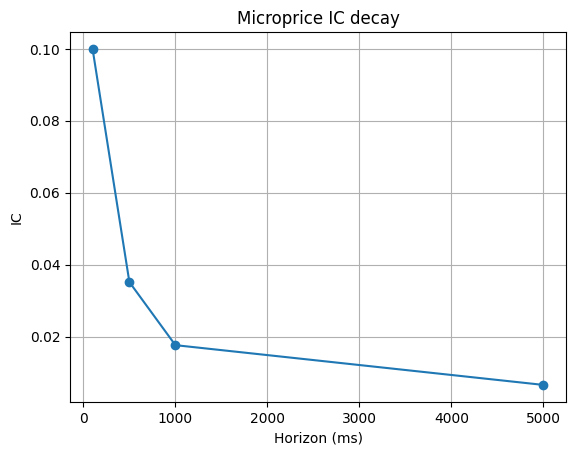

In [4]:
ic_curve = []

for h in horizons:
    y = df[f"y_{h}ms"].values
    x = df["micro_signal"].values

    mask = np.isfinite(x) & np.isfinite(y)

    ic_curve.append(ic(x[mask], y[mask]))

plt.plot(horizons, ic_curve, marker="o")
plt.title("Microprice IC decay")
plt.xlabel("Horizon (ms)")
plt.ylabel("IC")
plt.grid()
plt.show()

In [5]:
"""
So your model is approximately:

future_return_100ms
≈
5.519918083330967 x micro_signal

You can probably ignore the intercept.

"""

print("intercept:", models[100]["intercept"])
print("beta:", models[100]["beta"])
print("ic:", models[100]["ic"])

intercept: 9.824148104968269e-08
beta: 1.8394571133179365
ic: 0.09997042063672913


In [6]:
artifact = {
    "model_name": "micro_signal",
    "target": "(microprice - mid / mid)",
    "horizon_ms": 100,
    "intercept": models[100]["intercept"],
    "beta": models[100]["beta"],
    "ic": models[100]["ic"]
}

joblib.dump(artifact, "data/micro_signal_model_4.pkl")

['data/micro_signal_model_4.pkl']

In [7]:
def export_micro_signal(model_name, target, horizon_ms):
    artifact = {
        "model_name": model_name,
        "target": target,
        "horizon_ms": horizon_ms,
        "intercept": float(models[horizon_ms]["intercept"]),
        "beta": float(models[horizon_ms]["beta"]),
        "ic": float(models[horizon_ms]["ic"]),
        "rank_ic": float(models[horizon_ms]["rank_ic"])
    }

    with open(f"data/{model_name}.json", "w") as f:
        json.dump(artifact, f, indent=4)

    print(f"['data/{model_name}.json']")

export_micro_signal(model_name="micro_signal_model_4", target="(microprice - mid) / mid", horizon_ms=100)

['data/micro_signal_model_4.json']
